# Green Line fare evasion (scenario revenue estimates)

In [36]:
import os
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

load_dotenv()
API_KEY = os.getenv("MBTA_API_KEY")
BASE_URL = "https://api-v3.mbta.com"
HEADERS = {"x-api-key": API_KEY} if API_KEY else {}

RIDERSHIP_URL = (
    "https://services1.arcgis.com/ceiitspzDAHrdGO1/arcgis/rest/services/"
    "Fall_2024_MBTA_Rail_Ridership_by_SDP_Time_Period_Route_Line_and_Stop/FeatureServer/0/query"
)

FARE = 2.40  # Current Green Line fare (as of 03/2026)

 # Based on a recent news report from the MBTA that estimated fare evasion rates of 56.5% 
    # for above-ground lines due to the contactless payment system as of Sept. 2024 and 1-2% for underground lines.
    # This is a simplified approach but provides a starting point for estimation.
    # https://www.nbcboston.com/investigations/after-mbta-implements-new-payment-system-rampant-fare-evasion-on-green-line/3707620/
EVASION_SCENARIOS = {
    "low": {"above_ground": 0.2, "underground": 0.01}, #Just a guess for low evasion scenario
    "base": {"above_ground": 0.565, "underground": 0.02}, #From reports of 56.5% evasion for above-ground lines and 1-2% for underground lines as of Sept. 2024
    "high": {"above_ground": 0.95, "underground": 0.05}, #Another guess for high evasion scenario and no evidence to back it up, but just to see the potential impact if evasion were almost 100%.
}

TIME_PERIOD_HOURS = {
    "VERY_EARLY_MORNING": 1.5,
    "EARLY_AM": 1.5,
    "AM_PEAK": 2.0,
    "MIDDAY_BASE": 2.5,
    "MIDDAY_SCHOOL": 3.0,
    "PM_PEAK": 3.0,
    "EVENING": 2.5,
    "LATE_EVENING": 2.5,
    "NIGHT": 1.5,
    "OFF_PEAK": 6.0,
}


In [37]:
GREEN_LINE_BRANCHES = {
    "Green-B": "B Branch",
    "Green-C": "C Branch",
    "Green-D": "D Branch",
    "Green-E": "E Branch",
}

STOP_TO_BRANCH = {
    "B Branch": [
        "Blandford Street", "Boston University East", "Boston University Central",
        "Amory Street", "Babcock Street", "Packard's Corner", "Harvard Avenue",
        "Griggs Street", "Allston Street", "Warren Street", "Washington Street",
        "Sutherland Road", "Chiswick Road", "Chestnut Hill Avenue", "South Street",
        "Boston College",
    ],
    "C Branch": [
        "Saint Mary's Street", "Hawes Street", "Kent Street", "Saint Paul Street",
        "Coolidge Corner", "Summit Avenue", "Brandon Hall", "Fairbanks Street",
        "Washington Square", "Tappan Street", "Dean Road", "Englewood Avenue",
        "Cleveland Circle",
    ],
    "D Branch": [
        "Fenway", "Longwood", "Brookline Village", "Brookline Hills", "Beaconsfield",
        "Reservoir", "Chestnut Hill", "Newton Centre", "Newton Highlands", "Eliot",
        "Waban", "Woodland", "Riverside",
    ],
    "E Branch": [
        "Prudential", "Symphony", "Northeastern University", "Museum of Fine Arts",
        "Longwood Medical Area", "Brigham Circle", "Fenwood Road", "Mission Park",
        "Riverway", "Back of the Hill", "Heath Street",
    ],
}

UNDERGROUND_STOPS = {"Prudential", "Symphony"}


def fetch_ridership():
    print("Fetching MBTA ridership (ArcGIS)...")
    all_rows, offset, batch_size = [], 0, 500
    while True:
        params = {
            "where": "1=1",
            "outFields": "*",
            "outSR": 4326,
            "f": "json",
            "resultOffset": offset,
            "resultRecordCount": batch_size,
        }
        r = requests.get(RIDERSHIP_URL, params=params, timeout=120)
        r.raise_for_status()
        data = r.json()
        features = data.get("features", [])
        if not features:
            break
        all_rows.extend(f["attributes"] for f in features)
        if len(features) < batch_size:
            break
        offset += batch_size
    df = pd.DataFrame(all_rows)
    green = df[df["route_id"].str.startswith("Green", na=False)].copy()
    print(f"  → {len(green)} Green Line rows")
    return green


def fetch_stop_metadata():
    print("Fetching stop metadata (MBTA v3)...")
    if not API_KEY:
        print("  (no MBTA_API_KEY — skipping API; stop_count merge will be empty)")
        return pd.DataFrame(columns=["branch", "stop_name", "latitude", "longitude"])
    rows = []
    for route_id, branch_name in GREEN_LINE_BRANCHES.items():
        r = requests.get(
            f"{BASE_URL}/stops",
            headers=HEADERS,
            params={"filter[route]": route_id, "include": "facilities"},
            timeout=60,
        )
        r.raise_for_status()
        for stop in r.json().get("data", []):
            attr = stop.get("attributes", {})
            rows.append({
                "branch": branch_name,
                "stop_name": attr.get("name"),
                "latitude": attr.get("latitude"),
                "longitude": attr.get("longitude"),
            })
        print(f"  → {branch_name}")
    return pd.DataFrame(rows)


In [38]:
def _boarding_column(df):
    if "average_ons" in df.columns:
        return "average_ons"
    if "total_ons" in df.columns:
        return "total_ons"
    return None


def evasion_rate_for_stop(stop_name, scenario_key):
    rates = EVASION_SCENARIOS[scenario_key]
    if stop_name in UNDERGROUND_STOPS:
        return rates["underground"]
    return rates["above_ground"]


def estimate_evasion_scenarios(df_ridership, df_stops):
    col = _boarding_column(df_ridership)
    if col is None or "route_id" not in df_ridership.columns:
        print("Missing columns:", df_ridership.columns.tolist())
        return pd.DataFrame()

    stop_branch_map = {s: b for b, stops in STOP_TO_BRANCH.items() for s in stops}
    d = df_ridership.copy()
    d["branch_name"] = d["stop_name"].map(stop_branch_map)
    d = d.dropna(subset=["branch_name"])

    monthly = (
        d.groupby(["branch_name", "stop_name", "day_type_name", "time_period_name"])[col]
        .sum()
        .reset_index()
        .rename(columns={col: "ridership_count"})
    )

    if not df_stops.empty:
        sc = df_stops.groupby("branch").size().reset_index(name="stop_count")
        sc = sc.rename(columns={"branch": "branch_name"})
        monthly = monthly.merge(sc, on="branch_name", how="left")
    else:
        monthly["stop_count"] = pd.NA

    for key in EVASION_SCENARIOS:
        monthly[f"evasion_rate_{key}"] = monthly["stop_name"].apply(
            lambda n, k=key: evasion_rate_for_stop(n, k)
        )
        monthly[f"estimated_evaders_{key}"] = (
            monthly["ridership_count"] * monthly[f"evasion_rate_{key}"]
        ).round().astype(int)
        monthly[f"revenue_lost_{key}"] = monthly[f"estimated_evaders_{key}"] * FARE

    return monthly


In [39]:
t0 = time.time()
df_r = fetch_ridership()
df_s = fetch_stop_metadata()
df_e = estimate_evasion_scenarios(df_r, df_s)
print(f"Estimate rows: {len(df_e)} | elapsed {time.time() - t0:.1f}s")
df_e.head()


Fetching MBTA ridership (ArcGIS)...
  → 1540 Green Line rows
Fetching stop metadata (MBTA v3)...
  → B Branch
  → C Branch
  → D Branch
  → E Branch
Estimate rows: 583 | elapsed 12.2s


,branch_name,stop_name,day_type_name,time_period_name,ridership_count,stop_count,evasion_rate_low,estimated_evaders_low,revenue_lost_low,evasion_rate_base,estimated_evaders_base,revenue_lost_base,evasion_rate_high,estimated_evaders_high,revenue_lost_high
0,B Branch,Allston Street,Saturday,OFF_PEAK,413,23,0.2,83,199.2,0.565,233,559.2,0.95,392,940.8
1,B Branch,Allston Street,Sunday,OFF_PEAK,321,23,0.2,64,153.6,0.565,181,434.4,0.95,305,732.0
2,B Branch,Allston Street,Weekday,AM_PEAK,222,23,0.2,44,105.6,0.565,125,300.0,0.95,211,506.4
3,B Branch,Allston Street,Weekday,EARLY_AM,34,23,0.2,7,16.8,0.565,19,45.6,0.95,32,76.8
4,B Branch,Allston Street,Weekday,EVENING,46,23,0.2,9,21.6,0.565,26,62.4,0.95,44,105.6


In [40]:
# Totals and range across scenarios
scenario_keys = list(EVASION_SCENARIOS.keys())
totals = {k: df_e[f"revenue_lost_{k}"].sum() for k in scenario_keys}
evaders = {k: df_e[f"estimated_evaders_{k}"].sum() for k in scenario_keys}

summary = pd.DataFrame([
    {"metric": "estimated_evaders (monthly, sum of cells)", **{k: evaders[k] for k in scenario_keys}},
    {"metric": f"revenue_lost @ ${FARE:.2f} fare", **{k: totals[k] for k in scenario_keys}},
])
display(summary)

by_branch = df_e.groupby("branch_name")[[f"revenue_lost_{k}" for k in scenario_keys]].sum()
by_branch["range_width"] = by_branch[f"revenue_lost_high"] - by_branch[f"revenue_lost_low"]
display(by_branch.sort_values("revenue_lost_base", ascending=False))


,metric,low,base,high
0,"estimated_evaders (monthly, sum of cells)",10918.0,30779.0,51950.0
1,revenue_lost @ $2.40 fare,26203.2,73869.6,124680.0


,revenue_lost_low,revenue_lost_base,revenue_lost_high,range_width
branch_name,,,,
B Branch,8760.0,24739.2,41596.8,32836.8
D Branch,6816.0,19274.4,32421.6,25605.6
C Branch,6379.2,18067.2,30386.4,24007.2
E Branch,4248.0,11788.8,20275.2,16027.2


## Visualizations

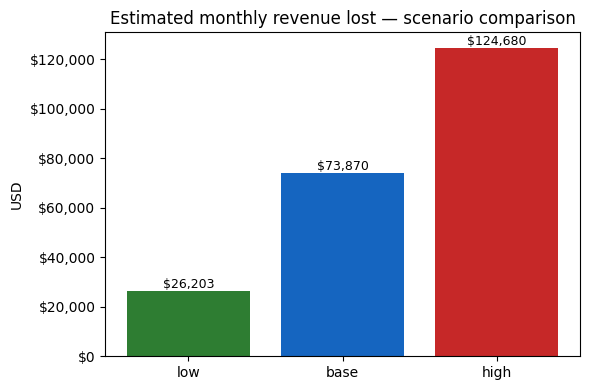

In [41]:
# Total revenue lost by scenario
fig, ax = plt.subplots(figsize=(6, 4))
keys = scenario_keys
vals = [totals[k] for k in keys]
colors = ["#2E7D32", "#1565C0", "#C62828"]
ax.bar(keys, vals, color=colors)
ax.set_title("Estimated monthly revenue lost — scenario comparison")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for i, v in enumerate(vals):
    ax.text(i, v, f"${v:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


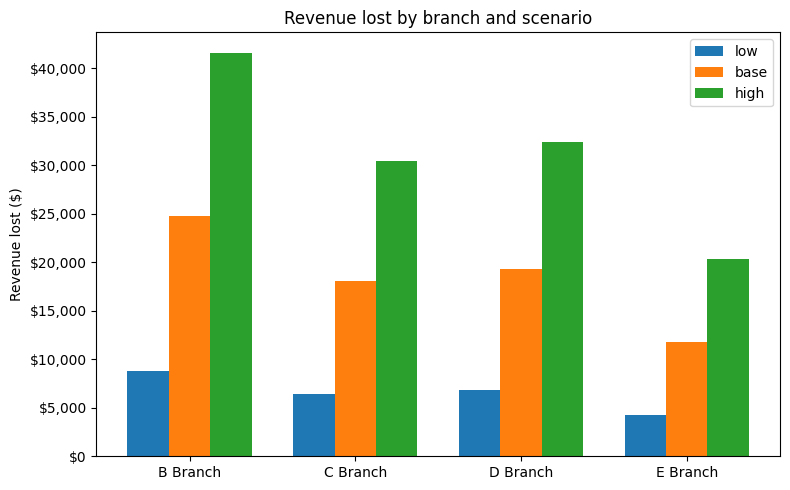

In [42]:
# Revenue lost by branch and scenario
fig, ax = plt.subplots(figsize=(8, 5))
branches = by_branch.index.tolist()
x = range(len(branches))
w = 0.25
for i, k in enumerate(scenario_keys):
    ax.bar([xi + (i - 1) * w for xi in x], by_branch[f"revenue_lost_{k}"], width=w, label=k)
ax.set_xticks(list(x))
ax.set_xticklabels(branches)
ax.set_ylabel("Revenue lost ($)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Revenue lost by branch and scenario")
plt.tight_layout()
plt.show()


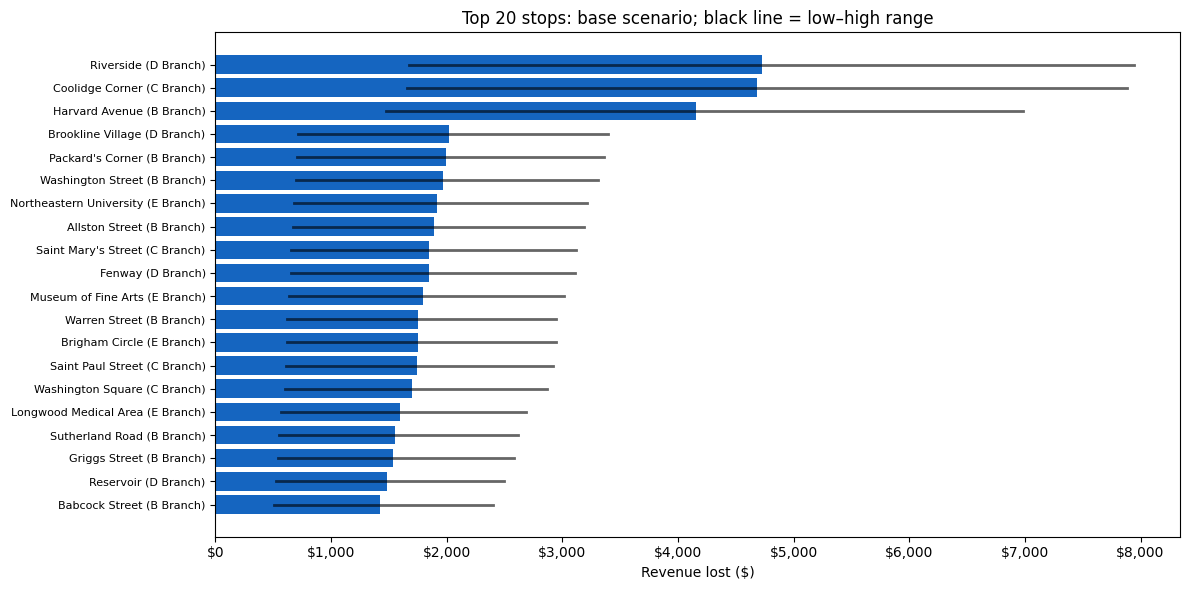

In [ ]:
# Ranking stops by base scenario with low–high whisker
stop_base = (
    df_e.groupby(["stop_name", "branch_name"], as_index=False)
    .agg(
        low=("revenue_lost_low", "sum"),
        base=("revenue_lost_base", "sum"),
        high=("revenue_lost_high", "sum"),
    )
    .sort_values("base", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
y = range(len(stop_base))
ax.barh(y, stop_base["base"], color="#1565C0", label="base")
for yi, (_, row) in enumerate(stop_base.iterrows()):
    ax.plot([row["low"], row["high"]], [yi, yi], color="black", linewidth=2, alpha=0.6)
ax.set_yticks(list(y))
ax.set_yticklabels(stop_base["stop_name"] + " (" + stop_base["branch_name"] + ")", fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Revenue lost ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Top 20 stops: base scenario; black line = low–high range")
plt.tight_layout()
plt.show()


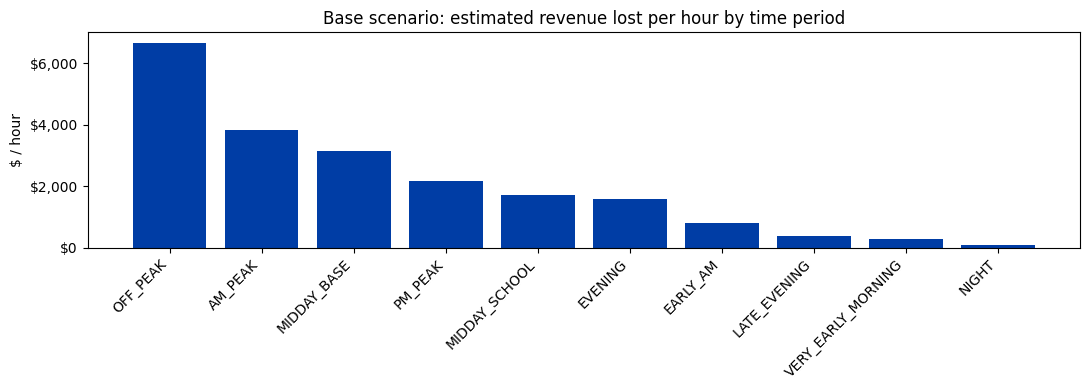

In [ ]:
# Revenue per hour by time period (base scenario)
summary_tp = df_e.groupby("time_period_name")["revenue_lost_base"].sum().reset_index()
summary_tp["hours"] = summary_tp["time_period_name"].map(TIME_PERIOD_HOURS)
summary_tp["revenue_per_hour"] = summary_tp["revenue_lost_base"] / summary_tp["hours"]
summary_tp = summary_tp.sort_values("revenue_per_hour", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(summary_tp["time_period_name"], summary_tp["revenue_per_hour"], color="#003DA5")
ax.set_title("Base scenario: estimated revenue lost per hour by time period")
ax.set_ylabel("$ / hour")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


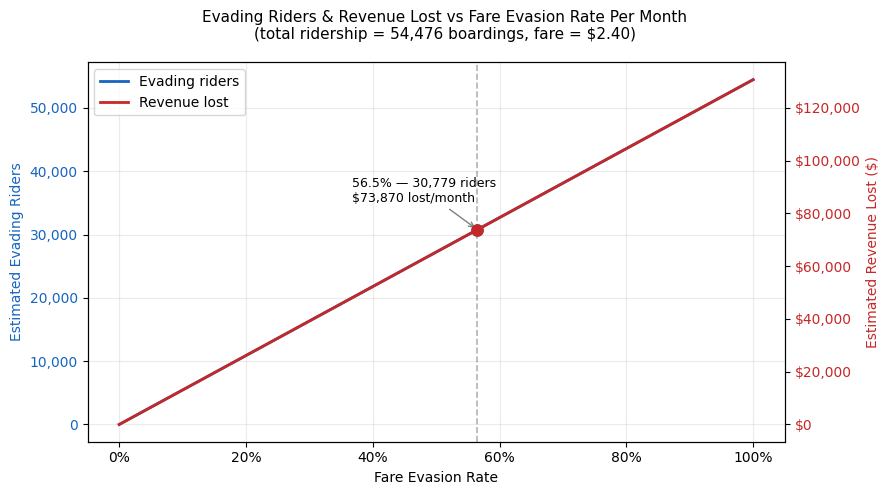

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

actual_ridership = df_e["estimated_evaders_base"].sum() / 0.565

evasion = np.linspace(0, 1.0, 300)
evaders = actual_ridership * evasion
revenue_lost = evaders * FARE

fig, ax1 = plt.subplots(figsize=(9, 5))

# Left y-axis: evading riders
ax1.plot(evasion, evaders, color="#1565C0", linewidth=2, label="Evading riders")
ax1.set_xlabel("Fare Evasion Rate")
ax1.set_ylabel("Estimated Evading Riders", color="#1565C0")
ax1.tick_params(axis="y", labelcolor="#1565C0")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Right y-axis: revenue lost
ax2 = ax1.twinx()
ax2.plot(evasion, revenue_lost, color="#C62828", linewidth=2, label="Revenue lost")
ax2.set_ylabel("Estimated Revenue Lost ($)", color="#C62828")
ax2.tick_params(axis="y", labelcolor="#C62828")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax1.grid(alpha=0.25)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle(
    f"Evading Riders & Revenue Lost vs Fare Evasion Rate Per Month\n"
    f"(total ridership = {actual_ridership:,.0f} boardings, fare = ${FARE:.2f})",
    fontsize=11
)

mark_rate = 0.565
mark_evaders = actual_ridership * mark_rate
mark_revenue = mark_evaders * FARE

ax1.axvline(mark_rate, color="grey", linewidth=1.2, linestyle="--", alpha=0.6)
ax1.plot(mark_rate, mark_evaders, "o", color="#1565C0", markersize=8, zorder=5)
ax2.plot(mark_rate, mark_revenue, "o", color="#C62828", markersize=8, zorder=5)

ax1.annotate(
    f"56.5% — {mark_evaders:,.0f} riders\n${mark_revenue:,.0f} lost/month",
    xy=(mark_rate, mark_evaders), xycoords=("data", "data"),
    xytext=(-90, 20), textcoords="offset points",
    fontsize=9, color="black",
    arrowprops=dict(arrowstyle="->", color="grey"),
)

plt.tight_layout()
plt.savefig("visualizations/EvadingRiders&RevenueLostvsFareEvasionRatePerMonth.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
out_path = "fare_evasion_estimates_scenarios.csv"
df_e.to_csv(out_path, index=False)
print("Saved:", out_path)


Saved: fare_evasion_estimates_scenarios.csv
